Training Recommendation Engine...
Epoch 1/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - loss: 9.0457 - val_loss: 1.9806
Epoch 2/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - loss: 1.2907 - val_loss: 1.0348
Epoch 3/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.9475 - val_loss: 0.9403
Epoch 4/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.8759 - val_loss: 0.9075
Epoch 5/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.8287 - val_loss: 0.8863

--- Recommendation Results for User #10 ---
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
Movie ID 1: Predicted Score 3.32/5.0
Movie ID 50: Predicted Score 3.55/5.0
Movie ID 100: Predicted Score 3.67/5.0
Movie ID 200: Predicted Score 3.64/5.0
Movie ID 500: Predicted Score 3.43/5.0


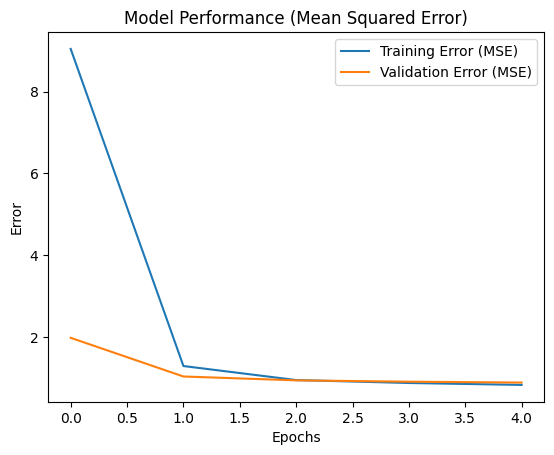

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Embedding, Flatten, Dot, Dense, Add
from tensorflow.keras.optimizers import Adam

# 1. LOAD DATASET (MovieLens 100k)
print("Downloading MovieLens Dataset...")
url = "https://files.grouplens.org/datasets/movielens/ml-100k/u.data"
columns = ['user_id', 'item_id', 'rating', 'timestamp']
df = pd.read_csv(url, sep='\t', names=columns)

# Map IDs to start at 0 (Required for Embeddings)
df.user_id = df.user_id.astype('category').cat.codes.values
df.item_id = df.item_id.astype('category').cat.codes.values

n_users = df.user_id.nunique()
n_items = df.item_id.nunique()

# 2. MATRIX FACTORIZATION MODEL (Collaborative Filtering)
def build_model(n_users, n_items, latent_dim=50):
    # User Pathway
    user_input = Input(shape=(1,), name="User-Input")
    user_embedding = Embedding(n_users, latent_dim, name="User-Embedding")(user_input)
    user_vec = Flatten(name="User-Flatten")(user_embedding)

    # Item (Movie) Pathway
    item_input = Input(shape=(1,), name="Item-Input")
    item_embedding = Embedding(n_items, latent_dim, name="Item-Embedding")(item_input)
    item_vec = Flatten(name="Item-Flatten")(item_embedding)

    # Dot Product (The "Matrix Factorization" core)
    dot_product = Dot(axes=1, name="Similarity-Dot-Product")([user_vec, item_vec])

    model = Model([user_input, item_input], dot_product)
    model.compile(optimizer=Adam(learning_rate=0.001), loss='mean_squared_error')
    return model

model = build_model(n_users, n_items)

# 3. TRAINING
X = df[['user_id', 'item_id']].values
y = df['rating'].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training Recommendation Engine...")
history = model.fit([X_train[:, 0], X_train[:, 1]], y_train,
                    batch_size=64, epochs=5,
                    validation_data=([X_test[:, 0], X_test[:, 1]], y_test))

# 4. EVALUATION & RESULTS
print("\n--- Recommendation Results for User #10 ---")
# Pick a random user and predict ratings for 5 movies they haven't seen
user_id = 10
unseen_items = np.array([1, 50, 100, 200, 500]) # Example Movie IDs
predicted_ratings = model.predict([np.array([user_id]*5), unseen_items])

for i, rating in enumerate(predicted_ratings):
    print(f"Movie ID {unseen_items[i]}: Predicted Score {rating[0]:.2f}/5.0")

# 5. VISUALIZING ERROR (Evaluation Metric)
plt.plot(history.history['loss'], label='Training Error (MSE)')
plt.plot(history.history['val_loss'], label='Validation Error (MSE)')
plt.title('Model Performance (Mean Squared Error)')
plt.xlabel('Epochs')
plt.ylabel('Error')
plt.legend()
plt.show()

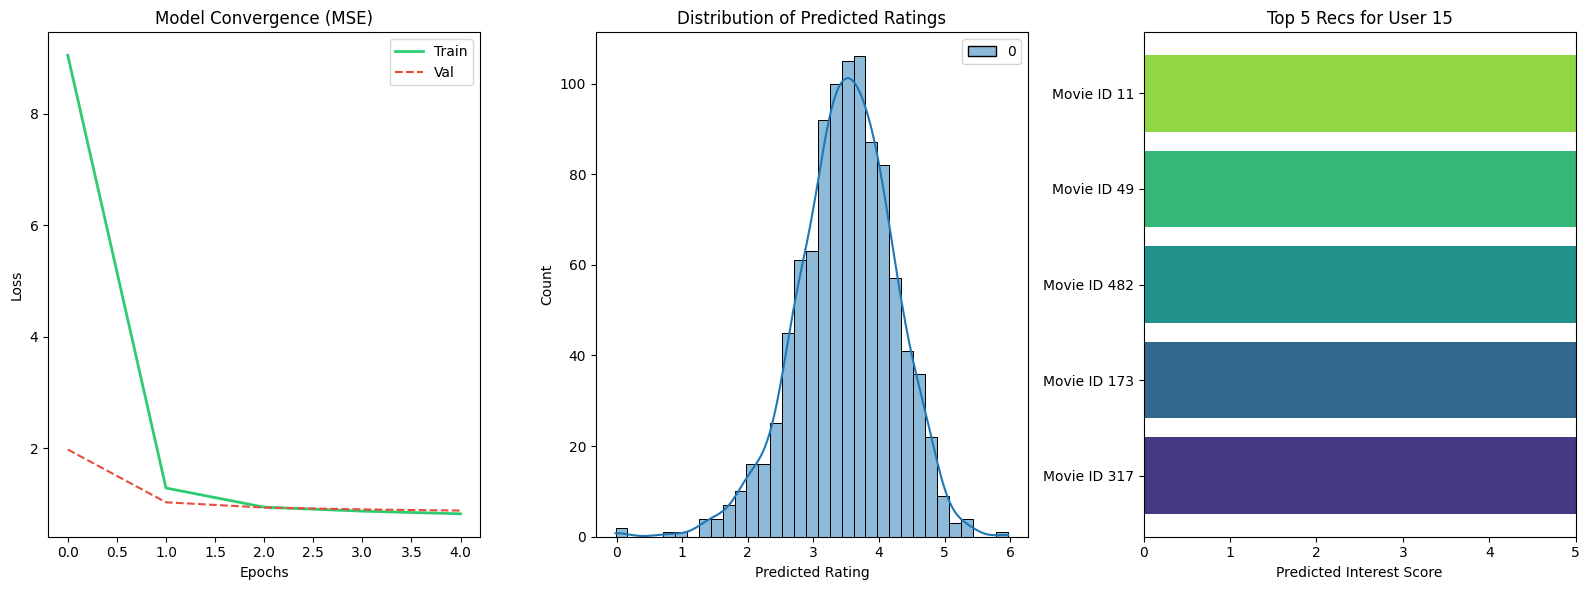

In [2]:
import seaborn as sns

# 1. Create a "Top Recommendations" Table for a specific user
def get_recommendations(user_id, num_recs=5):
    # Get all movie IDs
    all_movies = np.array(list(range(n_items)))
    # Predict ratings for all movies for this specific user
    user_array = np.array([user_id] * n_items)
    preds = model.predict([user_array, all_movies], verbose=0).flatten()

    # Sort and get top indices
    top_indices = preds.argsort()[-num_recs:][::-1]
    return top_indices, preds[top_indices]

user_to_test = 15 # You can change this ID
movie_ids, scores = get_recommendations(user_to_test)

# 2. Plotting the Dashboard
plt.figure(figsize=(16, 6))

# Subplot 1: MSE Loss (Your current graph)
plt.subplot(1, 3, 1)
plt.plot(history.history['loss'], label='Train', color='#2ecc71', linewidth=2)
plt.plot(history.history['val_loss'], label='Val', color='#e74c3c', linestyle='--')
plt.title('Model Convergence (MSE)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Subplot 2: Predicted Rating Distribution
plt.subplot(1, 3, 2)
test_preds = model.predict([X_test[:1000, 0], X_test[:1000, 1]], verbose=0)
sns.histplot(test_preds, kde=True, color='#3498db')
plt.title('Distribution of Predicted Ratings')
plt.xlabel('Predicted Rating')

# Subplot 3: Top 5 Recommendations for User
plt.subplot(1, 3, 3)
colors = sns.color_palette("viridis", len(movie_ids))
plt.barh([f"Movie ID {id}" for id in movie_ids], scores, color=colors)
plt.xlim(0, 5) # Ratings are 1-5
plt.title(f'Top 5 Recs for User {user_to_test}')
plt.xlabel('Predicted Interest Score')

plt.tight_layout()
plt.show()